#Indexing

##Preface: Chunking
To move further for advance task, first learn [basics of chunking/splitting](https://colab.research.google.com/drive/1QrbyIb4p1iS4EhLJE_7XWnoTOIYKTFyo?usp=sharing)
.

For an excellent review of document chunking, see this video from.
https://www.youtube.com/watch?v=8OJC21T2SL4

##Enviornment
(1) Packages

In [ ]:
! pip install langchain_community tiktoken langchain_groq langchainhub chromadb langchain yt_dlp ragatouille

  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of llama-cloud-services to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of llama-cloud-services to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 M

##Part 1: Multi-Representation Indexing<br>
Flow:

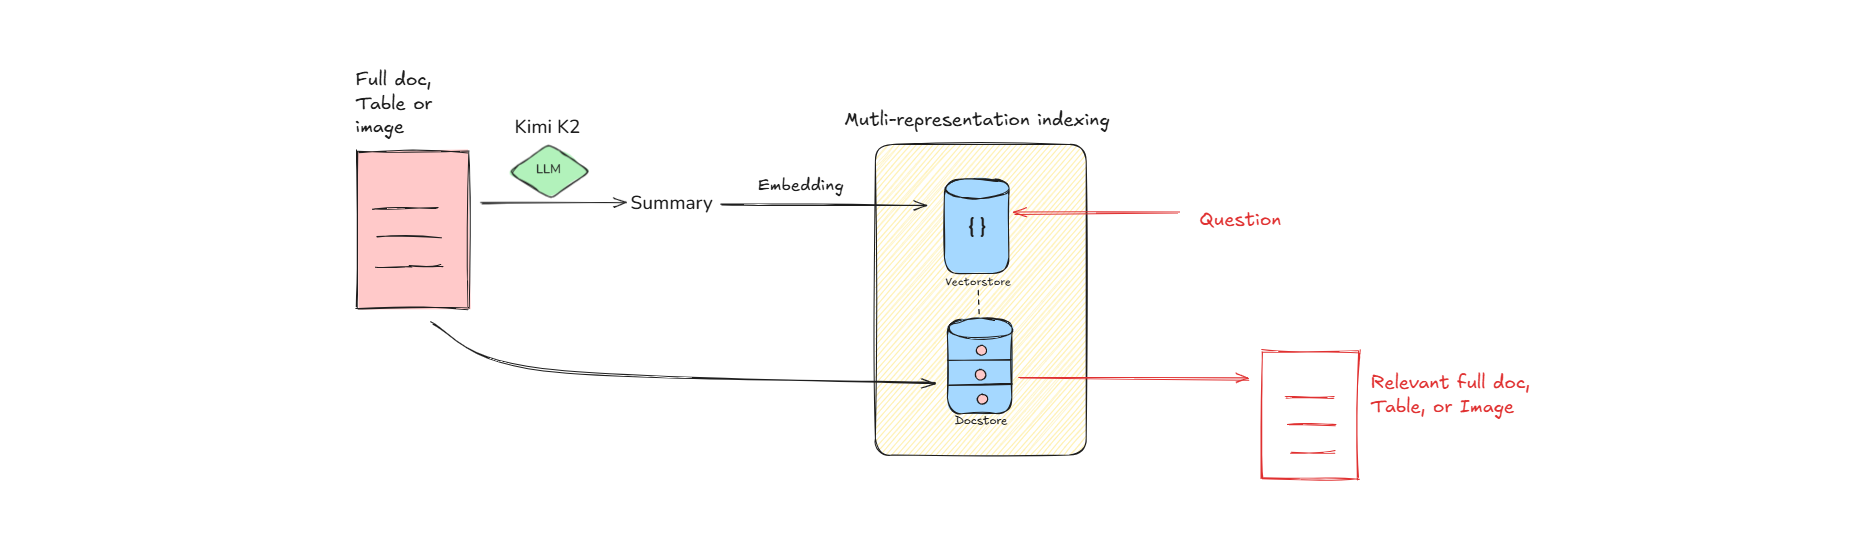

In [ ]:
from IPython.display import Image
display(Image("/content/Screenshot 2025-09-09 140951.png"))

Docs:

https://blog.langchain.dev/semi-structured-multi-modal-rag/

https://python.langchain.com/docs/modules/data_connection/retrievers/multi_vector

Paper:

https://arxiv.org/abs/2312.06648

In [ ]:
# Imports
import uuid
import os

import warnings
warnings.filterwarnings('ignore')
from google.colab import userdata

from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [ ]:
# Load dataset with web base loader
loader = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/")
docs = loader.load()

loader = WebBaseLoader("https://lilianweng.github.io/posts/2024-02-05-human-data-quality/")
docs.extend(loader.load())

In [ ]:
chain = (
    {"doc": lambda x: x.page_content}
    | ChatPromptTemplate.from_template("Summarize the following document:\n\n{doc}")
    | ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct",max_retries=0)
    | StrOutputParser()
)

summaries = chain.batch(docs, {"max_concurrency": 5})

In [ ]:
# The vectorstore to use to index the child chunks
vectorstore = Chroma(collection_name="summaries",
              embedding_function=SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2"))

# The storage layer for the parent documents
store = InMemoryByteStore()
id_key = "doc_id"

# The retriever
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    byte_store=store,
    id_key=id_key,
)
doc_ids = [str(uuid.uuid4()) for _ in docs]

# Docs linked to summaries
summary_docs = [
    Document(page_content=s, metadata={id_key: doc_ids[i]})
    for i, s in enumerate(summaries)
]

# Add
retriever.vectorstore.add_documents(summary_docs)
retriever.docstore.mset(list(zip(doc_ids, docs)))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
query = "Memory in agents"
sub_docs = vectorstore.similarity_search(query,k=1)
sub_docs[0]

Document(metadata={'doc_id': '234ed76d-6c08-47aa-b9f4-eb7c07394d46'}, page_content='## Summary of LLM-Powered Autonomous Agents\n\nThe article discusses the concept of LLM (Large Language Model) powered autonomous agents, which are systems that use LLMs as their core controller. These agents have the potential to perform complex tasks and make decisions autonomously.\n\n### Agent System Overview\n\nAn LLM-powered autonomous agent system consists of three key components:\n\n1. **Planning**: The agent breaks down large tasks into smaller, manageable subgoals, and uses self-reflection to improve the quality of final results.\n2. **Memory**: The agent uses short-term and long-term memory to retain and recall information over extended periods.\n3. **Tool Use**: The agent learns to call external APIs to gather missing information, execute code, and access proprietary information sources.\n\n### Component One: Planning\n\n* **Task Decomposition**: The agent breaks down complex tasks into smal

In [ ]:
retrieved_docs = retriever.get_relevant_documents(query,n_results=2)
print(retrieved_docs[0].page_content[0:1000], "/n")







LLM Powered Autonomous Agents | Lil'Log







































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


 


Table of Contents



Agent System Overview

Component One: Planning

Task Decomposition

Self-Reflection


Component Two: Memory

Types of Memory

Maximum Inner Product Search (MIPS)


Component Three: Tool Use

Case Studies

Scientific Discovery Agent

Generative Agents Simulation

Proof-of-Concept Examples


Challenges

Citation

References





Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.


##Part 2: ColBERT

1. **RAGatouille**

   * Provides a simple interface to use **ColBERT** for retrieval (indexing + searching).
   * Handles preprocessing, splitting, and building the ColBERT index under the hood.

2. **Document Encoding (Indexing Phase)**

   * ColBERT passes each passage through BERT.
   * Instead of pooling into one vector, it keeps **a contextualized embedding for every token** in the passage.
   * These token embeddings are stored in the ColBERT index.

3. **Query Encoding (Search Phase)**

   * At search time, the query is also encoded into **token-level embeddings**.

4. **Late Interaction (MaxSim)**

   * For each query token embedding:

     * Find the **most similar document token embedding** (dot product).
   * Take the **maximum similarity** for that query token.
   * Sum these max values across all query tokens → this becomes the **document score**.

   Formula:

   $$
   \text{score}(Q, D) = \sum_{q \in Q} \max_{d \in D}(q \cdot d)
   $$

   [Read the documentation for deep intuition](https://python.langchain.com/docs/integrations/retrievers/ragatouille/)

In [ ]:
# imports
from langchain.storage import InMemoryByteStore
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma
from langchain.retrievers.multi_vector import MultiVectorRetriever

In [ ]:
from ragatouille import RAGPretrainedModel
RAG = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

W0909 18:11:53.858000 262 torch/utils/cpp_extension.py:118] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


artifact.metadata: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[Sep 09, 18:12:05] Loading segmented_maxsim_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...


In [ ]:
import requests

def get_wikipedia_page(title: str):
    """
    Retrieve the full text content of a Wikipedia page.

    :param title: str - Title of the Wikipedia page.
    :return: str - Full text content of the page as raw string.
    """
    # Wikipedia API endpoint
    URL = "https://en.wikipedia.org/w/api.php"

    # Parameters for the API request
    params = {
        "action": "query",
        "format": "json",
        "titles": title,
        "prop": "extracts",
        "explaintext": True,
    }

    # Custom User-Agent header to comply with Wikipedia's best practices
    headers = {"User-Agent": "RAGatouille_tutorial/0.0.1 (ben@clavie.eu)"}

    response = requests.get(URL, params=params, headers=headers)
    data = response.json()

    # Extracting page content
    page = next(iter(data["query"]["pages"].values()))
    return page["extract"] if "extract" in page else None

full_document = get_wikipedia_page("Hayao_Miyazaki")

In [ ]:
RAG.index(
    collection=[full_document],
    index_name="Miyazaki-123",
    max_document_length=180,
    split_documents=True,
)

---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Sep 09, 18:12:57] #> Creating directory .ragatouille/colbert/indexes/Miyazaki-123 


[Sep 09, 18:12:59] [0] 		 #> Encoding 124 passages..


100%|██████████| 4/4 [01:06<00:00, 16.53s/it]

[Sep 09, 18:14:05] [0] 		 avg_doclen_est = 132.11289978027344 	 len(local_sample) = 124
[Sep 09, 18:14:05] [0] 		 Creating 1,024 partitions.
[Sep 09, 18:14:05] [0] 		 *Estimated* 16,381 embeddings.
[Sep 09, 18:14:05] [0] 		 #> Saving the indexing plan to .ragatouille/colbert/indexes/Miyazaki-123/plan.json ..


used 20 iterations (6.71s) to cluster 15563 items into 1024 clusters
[0.04, 0.04, 0.038, 0.036, 0.033, 0.038, 0.035, 0.036, 0.035, 0.035, 0.035, 0.038, 0.035, 0.037, 0.036, 0.039, 0.032, 0.035, 0.035, 0.038, 0.034, 0.039, 0.038, 0.038, 0.04, 0.034, 0.042, 0.036, 0.035, 0.034, 0.037, 0.039, 0.039, 0.035, 0.036, 0.033, 0.035, 0.035, 0.036, 0.04, 0.036, 0.038, 0.035, 0.034, 0.037, 0.035, 0.037, 0.037, 0.039, 0.036, 0.033, 0.036, 0.037, 0.037, 0.037, 0.037, 0.036, 0.039, 0.038, 0.033, 0.037, 0.037, 0.036, 0.037, 0.036, 0.036, 0.038, 0.038, 0.035, 0.034, 0.037, 0.034, 0.034, 0.036, 0.038, 0.034, 0.034, 0.042, 0.034, 0.035, 0.036, 0.037, 0.034, 0.04, 0.033, 0.037, 0.037, 0.037, 0.034, 0.044, 0.038, 0.037, 0.033, 0.036, 0.035, 0.037, 0.04, 0.036, 0.039, 0.036, 0.04, 0.043, 0.037, 0.037, 0.037, 0.036, 0.037, 0.033, 0.037, 0.033, 0.038, 0.037, 0.036, 0.034, 0.039, 0.037, 0.037, 0.036, 0.039, 0.038, 0.033, 0.034, 0.034, 0.038, 0.033, 0.037, 0.035, 0.037]


0it [00:00, ?it/s]

...


100%|██████████| 4/4 [01:07<00:00, 16.77s/it]
1it [01:07, 67.38s/it]
100%|██████████| 1/1 [00:00<00:00, 670.77it/s]

[Sep 09, 18:15:20] #> Optimizing IVF to store map from centroids to list of pids..
[Sep 09, 18:15:20] #> Building the emb2pid mapping..
[Sep 09, 18:15:20] len(emb2pid) = 16382



100%|██████████| 1024/1024 [00:00<00:00, 51483.59it/s]

[Sep 09, 18:15:20] #> Saved optimized IVF to .ragatouille/colbert/indexes/Miyazaki-123/ivf.pid.pt
Done indexing!


'.ragatouille/colbert/indexes/Miyazaki-123'

In [ ]:
results = RAG.search(query="What animation studio did Miyazaki found?", k=3)
results

Loading searcher for index Miyazaki-123 for the first time... This may take a few seconds
[Sep 09, 18:15:26] #> Loading codec...
[Sep 09, 18:15:26] #> Loading IVF...
[Sep 09, 18:15:26] Loading segmented_lookup_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...
[Sep 09, 18:15:55] #> Loading doclens...


100%|██████████| 1/1 [00:00<00:00, 2416.07it/s]

[Sep 09, 18:15:55] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 359.13it/s]

[Sep 09, 18:15:55] Loading filter_pids_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...


[Sep 09, 18:16:26] Loading decompress_residuals_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...
Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: What animation studio did Miyazaki found?, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2054,  7284,  2996,  2106,  2771,  3148, 18637,  2179,
         1029,   102,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103])
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])



[{'content': '=== Studio Ghibli ===\n\n\n==== Foundation and Laputa (1985–1987) ====\n\nFollowing the success of Nausicaä of the Valley of the Wind, Miyazaki and Takahata founded the animation production company Studio Ghibli on June 15, 1985, as a subsidiary of Tokuma Shoten, with offices in Kichijōji designed by Miyazaki. The studio\'s name had been registered a year earlier; Miyazaki named it after the nickname of the Caproni Ca.309 aircraft, meaning "a hot wind that blows in the desert" in Italian.',
  'score': 25.740371704101562,
  'rank': 1,
  'document_id': 'e99cabda-e9ab-48de-a72f-962dbc4acfde',
  'passage_id': 42},
 {'content': 'Hayao Miyazaki (宮崎 駿 or 宮﨑 駿, Miyazaki Hayao; [mijaꜜzaki hajao]; born January 5, 1941) is a Japanese animator, filmmaker, and manga artist. He co-founded Studio Ghibli and serves as honorary chairman. Throughout his career, Miyazaki has attained international acclaim as a masterful storyteller and creator of Japanese animated feature films, and is wide

In [ ]:
retriever = RAG.as_langchain_retriever(k=3)
retriever.invoke("What animation studio did Miyazaki found?")

[Document(metadata={}, page_content='=== Studio Ghibli ===\n\n\n==== Foundation and Laputa (1985–1987) ====\n\nFollowing the success of Nausicaä of the Valley of the Wind, Miyazaki and Takahata founded the animation production company Studio Ghibli on June 15, 1985, as a subsidiary of Tokuma Shoten, with offices in Kichijōji designed by Miyazaki. The studio\'s name had been registered a year earlier; Miyazaki named it after the nickname of the Caproni Ca.309 aircraft, meaning "a hot wind that blows in the desert" in Italian.'),
 Document(metadata={}, page_content='Hayao Miyazaki (宮崎 駿 or 宮﨑 駿, Miyazaki Hayao; [mijaꜜzaki hajao]; born January 5, 1941) is a Japanese animator, filmmaker, and manga artist. He co-founded Studio Ghibli and serves as honorary chairman. Throughout his career, Miyazaki has attained international acclaim as a masterful storyteller and creator of Japanese animated feature films, and is widely regarded as one of the most accomplished filmmakers in the history of an

##Part 3: RAPTOR (Retrieval Augmented Passage Tree of thought Reasoning)

###Core Idea:

- Traditional RAG retrieves passages from an external knowledge base and lets the LLM generate an answer.

 - Tree-of-Thoughts (ToT) extends Chain-of-Thought (CoT) by allowing the model to explore multiple reasoning paths, evaluate them, and backtrack if needed.

- RAPTOR combines both: instead of retrieving flat passages only once, it organizes retrieved knowledge in a hierarchical tree structure where reasoning steps guide what to retrieve and which paths to pursue.
<br>

###Why RAPTOR ?
1. Flat retrieval -> Retrieves chunks independently often missing relationship between passages.
2. Context Fragmentation -> long document split into chunks lose coherence.
3. LLM reasonings -> Requires broader context than a single chunk.
<br>


### How RAPTOR Works

1. **Query Expansion & Retrieval**

   * The system takes the user query and retrieves initial passages.
   * These are structured as the **root of the reasoning tree**.

2. **Passage Tree Construction**

   * Each node (passage) can generate new sub-queries to explore related content.
   * Retrieval expands the tree, providing more context at each level.

3. **Tree-of-Thoughts Reasoning**

   * The LLM reasons step by step, evaluating different branches of the passage tree.
   * It can backtrack if a path is irrelevant and move to a more promising branch.

4. **Final Answer Generation**

   * The model synthesizes reasoning across multiple paths.
   * Instead of being limited to the "top-k" flat passages like in vanilla RAG, it uses a structured **tree of evidence**.



###Flow:


In [ ]:
from IPython.display import Image
display(Image("/content/RAPTOR Flow.png"))

Output hidden; open in https://colab.research.google.com to view.

Deep dive video:

https://www.youtube.com/watch?v=jbGchdTL7d0

Paper:

https://arxiv.org/pdf/2401.18059.pdf

Full code:

https://github.com/langchain-ai/langchain/blob/master/cookbook/RAPTOR.ipynb